In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.datasets import fetch_california_housing
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler

I0000 00:00:1780660044.159055   17168 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1780660044.162684   17168 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1780660044.516732   17168 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1780660045.983174   17168 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:0

In [5]:
df = fetch_california_housing()

In [7]:
X = df.data
y = df.target

In [9]:
X.shape

(20640, 8)

In [10]:
y.shape

(20640,)

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [12]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [42]:
model = tf.keras.Sequential([

    tf.keras.layers.Dense(
        64,
        activation='relu',
        input_shape=(8,),
        kernel_regularizer=tf.keras.regularizers.l2(0.001)
    ),

    tf.keras.layers.Dense(
        32,
        activation='relu',
        kernel_regularizer=tf.keras.regularizers.l2(0.001)
    ),

    tf.keras.layers.Dense(
        16,
        activation='relu',
        kernel_regularizer=tf.keras.regularizers.l2(0.001)
    ),

    tf.keras.layers.Dense(
        8,
        activation='relu',
        kernel_regularizer=tf.keras.regularizers.l2(0.001)
    ),

    tf.keras.layers.Dense(1)

])

/home/mynk/miniconda3/envs/ml/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [43]:
model.compile(
    loss=tf.keras.losses.mae,
    optimizer=tf.keras.optimizers.Adam(),
    metrics=['mae']
)

In [56]:
history = model.fit(X_train, y_train, epochs=150, validation_split=0.2)

Epoch 1/150


413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.3396 - mae: 0.3134 - val_loss: 0.3671 - val_mae: 0.3409
Epoch 2/150
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.3371 - mae: 0.3109 - val_loss: 0.3661 - val_mae: 0.3399
Epoch 3/150
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.3384 - mae: 0.3122 - val_loss: 0.3598 - val_mae: 0.3336
Epoch 4/150
413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3385 - mae: 0.3123 - val_loss: 0.3591 - val_mae: 0.3330
Epoch 5/150
413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3387 - mae: 0.3125 - val_loss: 0.3744 - val_mae: 0.3482
Epoch 6/150
413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3397 - mae: 0.3135 - val_loss: 0.3671 - val_mae: 0.3412
Epoch 7/150
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.3386 - mae: 0.3125 - val_loss: 0.3615 - val_mae: 0.3354
Epoch 8/150
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.3397 - mae: 0.3135 - val_loss: 0.3625 - val_mae: 0.3363
Epoch 9/150
413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss:

129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 492us/step


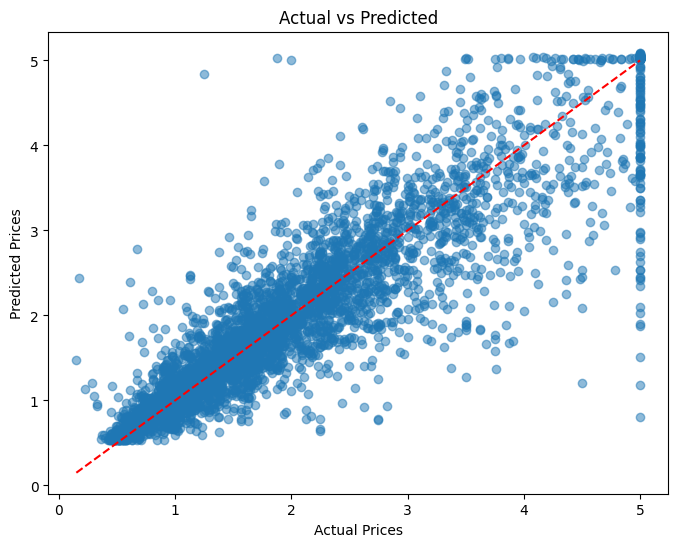

In [ ]:
y_pred = model.predict(X_test)

plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred, alpha=0.5)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted")

plt.show()

129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 387us/step


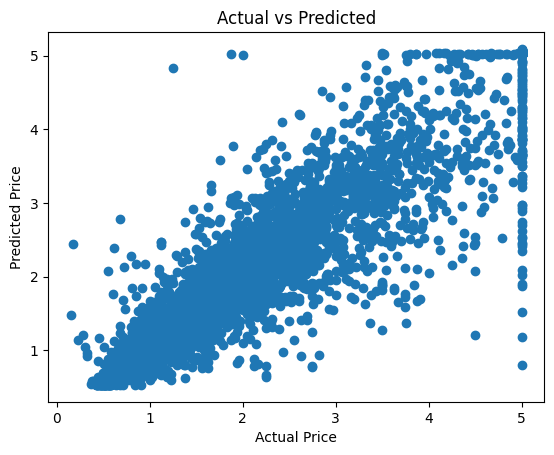

In [57]:
y_pred = model.predict(X_test)

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted")

plt.show()

In [58]:
from sklearn.metrics import r2_score

y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)

print("R2 Score:", r2)

129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 488us/step
R2 Score: 0.7933061064710287


In [59]:
from sklearn.metrics import r2_score

train_pred = model.predict(X_train)

test_pred = model.predict(X_test)

print("Train R²:", r2_score(y_train, train_pred))
print("Test R² :", r2_score(y_test, test_pred))

516/516 ━━━━━━━━━━━━━━━━━━━━ 0s 357us/step
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 379us/step
Train R²: 0.8178470580138203
Test R² : 0.7933061064710287


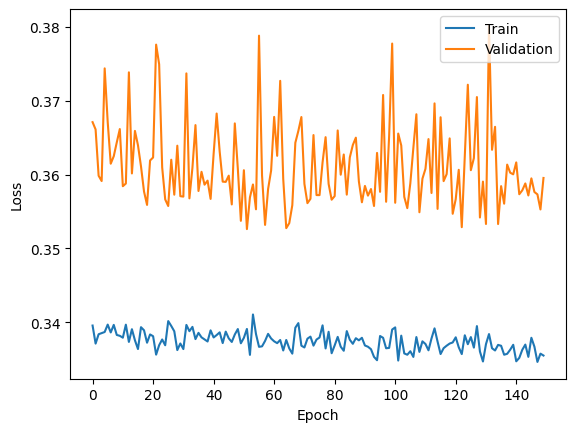

In [66]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend(["Train", "Validation"])

plt.show()